<a href="https://colab.research.google.com/github/jbvp4116/data-analysis-programming/blob/main/DataAnalysis_subject_personal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 데이터 분석하기
데이터 원본 링크: https://www.kaggle.com/datasets/muneebmuhammadali/student-ai-tools-vs-exam-scores

### 사전 세팅

In [2]:
!pip install koreanize_matplotlib
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (54.1 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [6]:
data_target = pd.read_csv('students_ai_usage.csv')
data_target.head() #정상적으로 데이터 읽었는지 확인

,age,education_level,study_hours_per_day,uses_ai,ai_tools_used,purpose_of_ai,grades_before_ai,grades_after_ai,daily_screen_time_hours
0,19,college,1.4,No,NaN,NaN,62,62,3
1,15,school,3.9,Yes,Copilot,Research,56,61,2
2,15,school,1.9,Yes,Copilot,Homework,75,88,5
3,15,school,2.8,No,NaN,NaN,55,55,3
4,19,college,2.7,No,NaN,NaN,59,59,3


### 기본적인 데이터 확인

In [9]:
print(data_target.info()) #데이터 칼럼 정보

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      100 non-null    int64  
 1   education_level          100 non-null    object 
 2   study_hours_per_day      100 non-null    float64
 3   uses_ai                  100 non-null    object 
 4   ai_tools_used            40 non-null     object 
 5   purpose_of_ai            40 non-null     object 
 6   grades_before_ai         100 non-null    int64  
 7   grades_after_ai          100 non-null    int64  
 8   daily_screen_time_hours  100 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 7.2+ KB
None


In [10]:
print(data_target.describe()) #데이터 통계

              age  study_hours_per_day  grades_before_ai  grades_after_ai  \
count  100.000000           100.000000         100.00000       100.000000   
mean    16.490000             2.987000          64.77000        68.700000   
std      1.702612             1.145713           6.16909         8.140806   
min     14.000000             1.000000          55.00000        55.000000   
25%     15.000000             1.975000          59.00000        61.000000   
50%     16.000000             2.800000          63.00000        69.000000   
75%     18.000000             4.025000          70.00000        74.000000   
max     19.000000             5.000000          75.00000        89.000000   

       daily_screen_time_hours  
count               100.000000  
mean                  4.340000  
std                   1.793479  
min                   2.000000  
25%                   3.000000  
50%                   4.000000  
75%                   6.000000  
max                   7.000000  


In [11]:
print(data_target.columns) #데이터 열 구성 확인

Index(['age', 'education_level', 'study_hours_per_day', 'uses_ai',
       'ai_tools_used', 'purpose_of_ai', 'grades_before_ai', 'grades_after_ai',
       'daily_screen_time_hours'],
      dtype='object')


In [40]:
# 신규 데이터(성적 상승량) 생성

data_target['grade_improvement'] = (data_target['grades_after_ai'] - data_target['grades_before_ai'])

### AI 사용 관련 분석

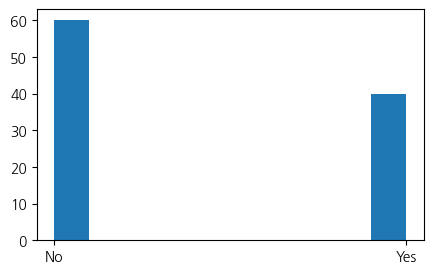

In [23]:
# AI를 사용하는 학생 수
plt.figure(figsize = (5, 3))
plt.hist(data_target.uses_ai)
plt.show()

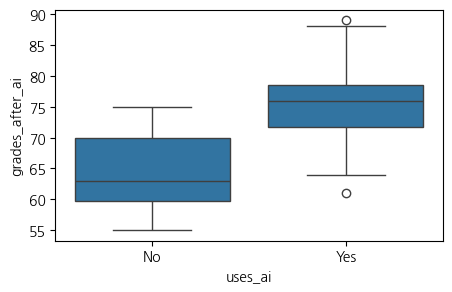

In [27]:
# AI를 사용한 학생과 사용하지 않은 학생의 성적 비교, 박스플롯
plt.figure(figsize = (5, 3))
sns.boxplot(data = data_target, x = 'uses_ai', y = 'grades_after_ai')
plt.show()

### AI 관련 통계

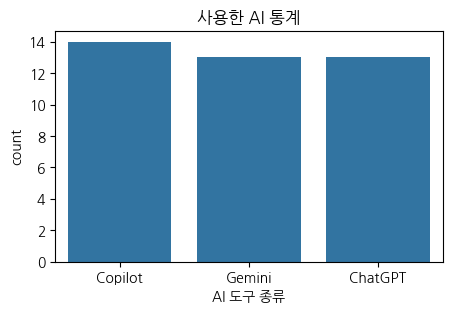

In [38]:
# AI 사용량 통계

plt.figure(figsize = (5, 3))
sns.countplot(data = data_target, x = 'ai_tools_used')

plt.title('사용한 AI 통계')
plt.xlabel('AI 도구 종류')
plt.show()

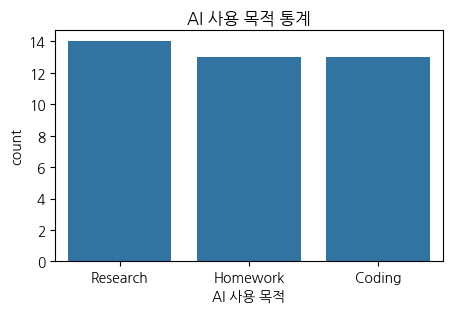

In [39]:
# AI 사용 목적 통계

plt.figure(figsize = (5, 3))

sns.countplot(data=data_target, x='purpose_of_ai')

plt.title('AI 사용 목적 통계')
plt.xlabel('AI 사용 목적')

plt.show()

### AI 사용에 따른 성적 상승량 분석

<Axes: xlabel='uses_ai', ylabel='grade_improvement'>

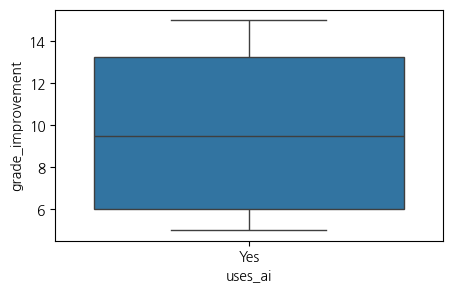

In [55]:
# AI 사용 전후 성적 상승량

data_target_aiused = data_target[data_target['uses_ai'] == 'Yes']

plt.figure(figsize = (5, 3))
sns.boxplot(data = data_target_aiused, x = 'uses_ai', y = 'grade_improvement')

In [52]:
# AI 사용 전후 성적 상승량 평균, 최대, 최소, 중앙값 계산 및 출력

print(data_target_aiused['grade_improvement'].describe())

count    40.000000
mean      9.825000
std       3.551002
min       5.000000
25%       6.000000
50%       9.500000
75%      13.250000
max      15.000000
Name: grade_improvement, dtype: float64


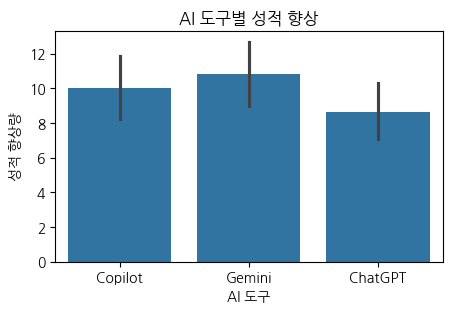

In [33]:
# 사용한 AI에 따른 성적 상승량

plt.figure(figsize = (5, 3))

sns.barplot(data=data_target_aiused, x='ai_tools_used', y='grade_improvement')

plt.title('AI 도구별 성적 향상')
plt.xlabel('AI 도구')
plt.ylabel('성적 향상량')

plt.show()

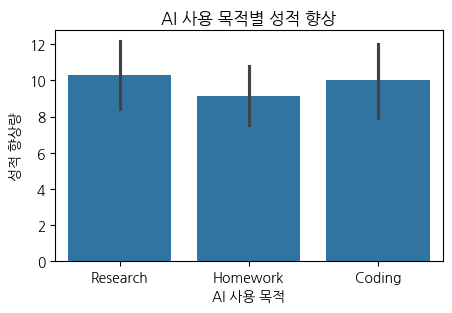

In [34]:
# AI 사용 목적에 따른 성적 상승량

plt.figure(figsize = (5, 3))

sns.barplot(data=data_target_aiused, x='purpose_of_ai', y='grade_improvement')

plt.title('AI 사용 목적별 성적 향상')
plt.xlabel('AI 사용 목적')
plt.ylabel('성적 향상량')

plt.show()

### AI 사용 여부와 공부 시간 관계 분석

/tmp/ipykernel_495/2308068482.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_target_aiused['study_group'] = pd.cut(data_target_aiused['study_hours_per_day'], bins = bins, labels = labels)


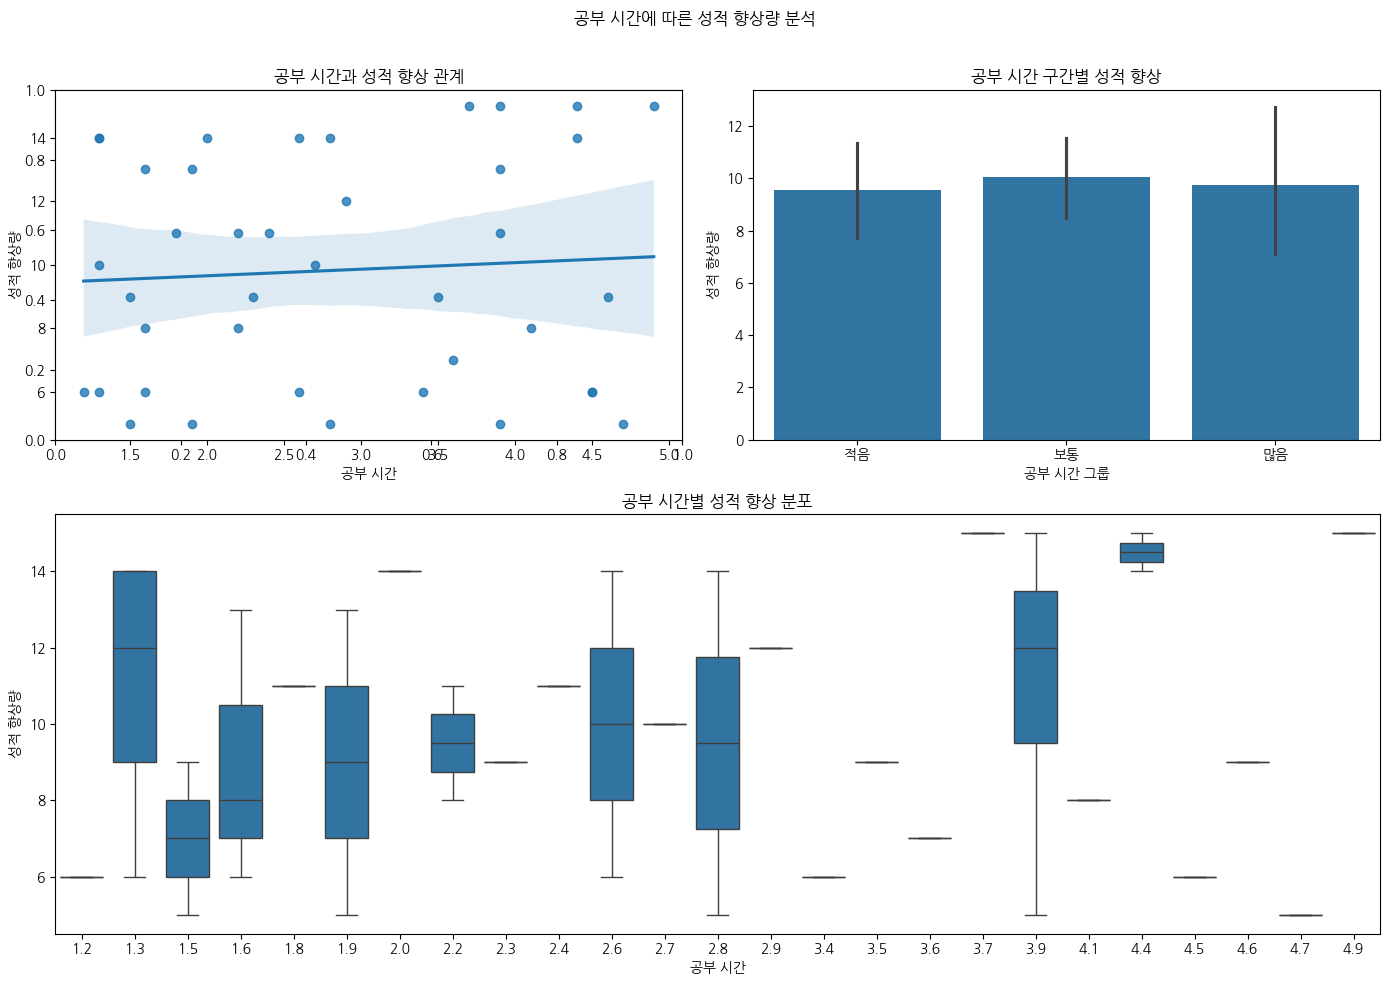

In [66]:
# 공부 시간에 따른 성적 향상량

bins = [0, 2, 4, 5]
labels = ['적음', '보통', '많음']

data_target_aiused['study_group'] = pd.cut(data_target_aiused['study_hours_per_day'], bins = bins, labels = labels)

fig = plt.figure(figsize=(14, 10))

fig.suptitle('공부 시간에 따른 성적 향상량 분석')

gs = fig.add_gridspec(2, 2, height_ratios = [1, 1.2])

pl1 = fig.add_subplot(gs[0, 0])

#공부 시간과 성적 향상 관계, 산점도 + 추세선
ax1 = fig.add_subplot(gs[0, 0])
sns.regplot(data = data_target_aiused, x = 'study_hours_per_day', y = 'grade_improvement',ax = ax1)

ax1.set_title('공부 시간과 성적 향상 관계')
ax1.set_xlabel('공부 시간')
ax1.set_ylabel('성적 향상량')

#공부 시간 구간별 성적 향상량
ax2 = fig.add_subplot(gs[0, 1])
sns.barplot(data = data_target_aiused, x = 'study_group', y = 'grade_improvement', ax = ax2)

ax2.set_title('공부 시간 구간별 성적 향상')
ax2.set_xlabel('공부 시간 그룹')
ax2.set_ylabel('성적 향상량')

#공부 시간별 성적 향상 분포
ax3 = fig.add_subplot(gs[1, :])
sns.boxplot(data = data_target_aiused, x = 'study_hours_per_day', y = 'grade_improvement', ax = ax3)

ax3.set_title('공부 시간별 성적 향상 분포')
ax3.set_xlabel('공부 시간')
ax3.set_ylabel('성적 향상량')

plt.tight_layout()
plt.subplots_adjust(top = 0.9)
plt.show()

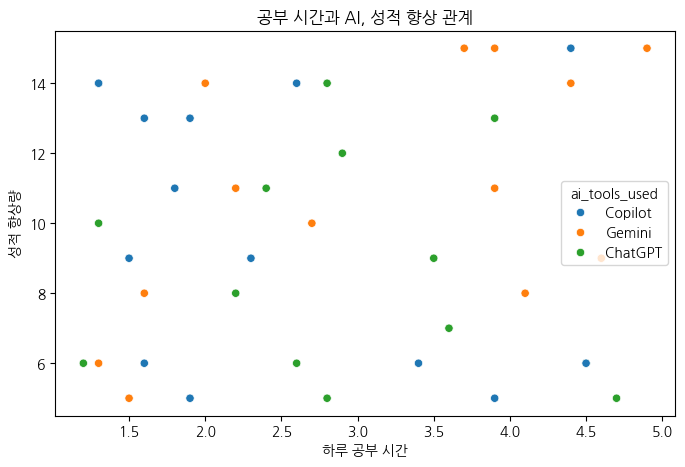

In [45]:
# 공부 시간과 AI 사용 여부, AI 사용 도구에 따른 산점도

plt.figure(figsize = (8, 5))

sns.scatterplot(data = data_target, x = 'study_hours_per_day', y = 'grade_improvement', hue = 'ai_tools_used')

plt.title('공부 시간과 AI, 성적 향상 관계')
plt.xlabel('하루 공부 시간')
plt.ylabel('성적 향상량')

plt.show()

<Figure size 800x500 with 0 Axes>

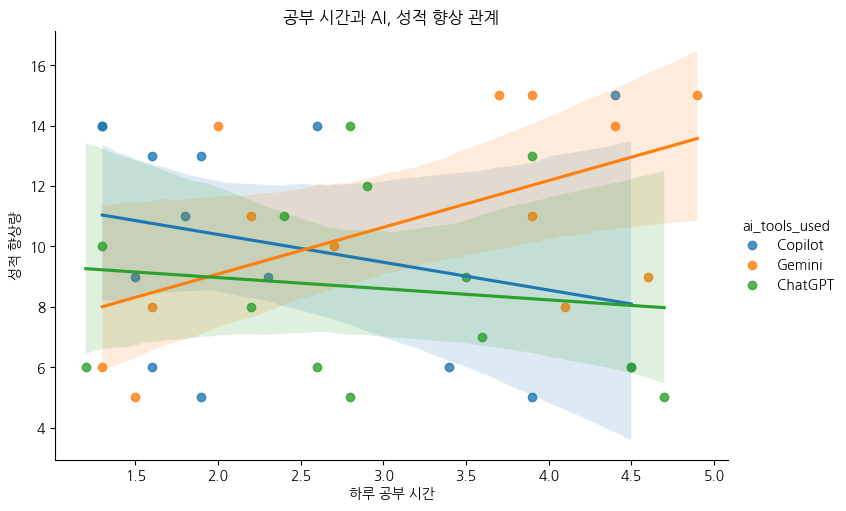

In [48]:
# 공부 시간과 AI 사용 여부, AI 사용 도구에 따른 산점도, 회귀선 추가

plt.figure(figsize = (8, 5))

sns.lmplot(data = data_target, x = 'study_hours_per_day', y = 'grade_improvement', hue = 'ai_tools_used', height = 5, aspect = 1.5)

plt.title('공부 시간과 AI, 성적 향상 관계')
plt.xlabel('하루 공부 시간')
plt.ylabel('성적 향상량')

plt.show()

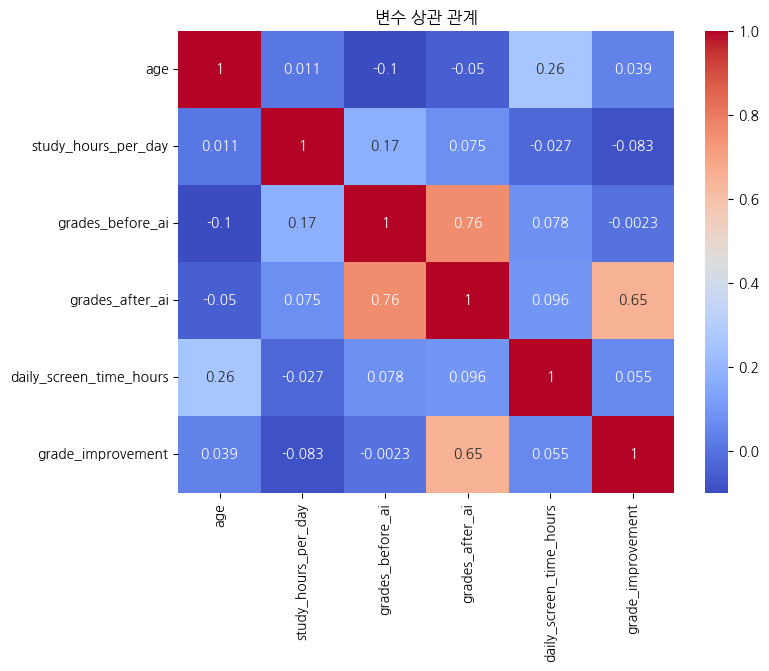

In [50]:
# 상관관계 heatmap

plt.figure (figsize = (8, 6))

sns.heatmap(data_target.select_dtypes(include = np.number).corr(), annot = True, cmap = 'coolwarm')
plt.title('변수 상관 관계')
plt.show()

## 분석 결과

AI를 사용한 학생은 40명, 사용하지 않은 학생은 60명

이중 AI를 사용한 학생의 성적 향상 폭은

*   평균 9.825
*   최소 5
*   최대 15
*   중앙값 9.5
*   표준편차 3.55

AI를 사용한 목적은 Research가 가장 많았음

AI 사용 시 성적이 향상하는 것을 관찰할 수 있었으나
공부 시간과 성적 향상량이 반드시 정비례하는 것은 아님을 확인하였음
